# Mixed Strategies, Beliefs, and Fictitious Play

Alex Ronczewski  
2026-07-15

## Outline

### Prerequisites

-   Notebook 1 of this stream. We reuse two of its main games: the
    detection game and the data pipeline game, and its central concepts,
    best response and Nash equilibrium.
-   Basic Python and `numpy` at the COMET-intermediate level.

### Learning Outcomes

By the end of this notebook you will be able to:

1.  Define a **mixed strategy** and compute expected payoffs against
    one.
2.  Explain why a predictable player can be exploited, and why games of
    pure conflict force unpredictability.
3.  Derive a mixed Nash equilibrium with the **indifference principle**,
    by hand and with `nashpy`.
4.  Implement **fictitious play**: form a belief from the opponent’s
    whole history and best respond to it.
5.  Interpret a mixed equilibrium as the long-run frequencies of a
    deterministic learning process.
6.  Show, with Shapley’s game, that belief-based learning does not
    always converge.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import nashpy as nash

## 1. From reacting to predicting

Notebook 1 ended with a chase and an empty list. In the detection game,
a fraud detector and a scalper bot each reacted to the other’s last
move, and the pair cycled through the four cells of the table forever.
Our equilibrium finder came back empty: that game has no pure Nash
equilibrium, no cell of the table where both players are content.

After a hundred rounds, the detector has a hundred observations of the
bot’s behaviour, and it uses only one of them, the most recent one.
Instead it should treat the history as data: what fraction of the time
has the bot attacked Channel A? That estimate is a **belief** about the
opponent, and acting on a belief instead of a single move is the upgrade
this notebook adds. This is also the first machine-learning idea in the
stream: the player fits a model of its opponent and best responds to the
model’s prediction.

Before we can build that player we need one more piece of theory. A
belief is a probability, and best responding to a probability only makes
sense once we can talk about strategies that are themselves
probabilities. So we start by introducing mixed strategies, then build
the learner.

First, re-encode the two games from Notebook 1 that we will need. In the
detection game the detector wants to screen the channel the bot attacks,
and the bot wants the opposite. In the data pipeline game two firms each
choose between adopting a shared data standard and keeping their legacy
setup.

In [2]:
M = np.array([[ 1, -1],
              [-1,  1]])          # detector's payoffs: rows screen A or B
channels = ["Channel A", "Channel B"]
detection_game = nash.Game(M, -M)

S = np.array([[4, 0],
              [3, 3]])            # firm 1's payoffs: rows Adopt or Legacy
standards = ["Adopt", "Legacy"]
standard_game = nash.Game(S, S.T)

## 2. Mixed strategies

A **mixed strategy** is a probability distribution over a player’s
actions: a vector $\sigma$ with one non-negative entry per action,
summing to one. The bot playing $\sigma = (0.6, 0.4)$ attacks Channel A
60% of the time and Channel B 40% of the time. A pure action is the
special case where all the probability sits in one entry: $(1, 0)$ means
attacking Channel A every round.

Payoffs against a mixed strategy are **expected payoffs**: weight each
cell of the table by the probability it gets visited, and add everything
up. If the detector plays mix $\sigma_1$ and the bot plays mix
$\sigma_2$, they randomize independently, so the cell $(a_1, a_2)$ is
visited with probability $\sigma_1(a_1)\,\sigma_2(a_2)$ and the
detector’s expected payoff is

$$
u_1(\sigma_1, \sigma_2) = \sum_{a_1} \sum_{a_2} \sigma_1(a_1)\, \sigma_2(a_2)\, u_1(a_1, a_2),
$$

each cell’s payoff times the probability of reaching it, summed over the
whole table.

Best responses now maximize expected payoff. If one of your actions has
a strictly higher expected payoff than the other against the mix you
face, your best response is pure: play the better action every round.
Mixing can only be a best response when your actions are exactly tied.
In the detection game this means that if the bot leans toward either
channel, however slightly, the detector’s best response is to screen
that channel every round, and the bot gets caught. Only mixes that keep
the opponent’s actions tied can survive, and which mixes those are
depends on the game’s payoffs.

### 2.1 The indifference principle

So what mix is safe? The one that leaves the opponent nothing to
exploit. The bot’s mix stops being exploitable exactly when it makes the
detector’s two actions equally good, when the detector is
**indifferent**. Write $q$ for the probability the bot attacks Channel
A. The detector’s expected payoffs are

$$
u_{\text{det}}(\text{screen A}) = q - (1 - q) = 2q - 1, \qquad
u_{\text{det}}(\text{screen B}) = -q + (1 - q) = 1 - 2q,
$$

and setting them equal gives $q = 1/2$. The same calculation for the
detector’s mix, using the bot’s payoffs, gives $1/2$ as well. So the
game Notebook 1 left without an equilibrium has one after all, just not
in pure actions: both players mix 50/50. The pair of mixes is a **mixed
Nash equilibrium**. Neither player can gain by deviating, because
against a 50/50 opponent every action pays the same, and 50/50 is the
only behaviour that offers the opponent no pattern to exploit.

> **Your mix is pinned down by your opponent’s payoffs**
>
> Read the derivation again and notice whose payoffs decided the bot’s
> mix: the detector’s. The bot chooses 50/50 because that is what makes
> the *detector* indifferent, and the detector’s mix is what makes the
> *bot* indifferent. In a mixed equilibrium each player’s probabilities
> are set by the other player’s incentives. This can feel backwards, and
> it is the single most common mistake made with mixed strategies.

The data pipeline game works the same way, and mixing is useful in it
for a different reason: the game has two pure equilibria. Write $p$ for
the probability that your rival adopts the standard. Adopting pays
$4p + 0(1-p) = 4p$, staying on Legacy pays $3p + 3(1-p) = 3$ no matter
what. Indifference requires

$$
4p = 3 \quad \Rightarrow \quad p = 0.75,
$$

so alongside the two pure equilibria from Notebook 1 there is a third
equilibrium hiding between them: both firms adopting 75% of the time.
There is a second, very useful way to read this number: it is a
**tipping point** of beliefs. If you think your rival adopts with
probability above 75%, your best response is to adopt; below 75%, you
should stay on the legacy pipeline. The mixed equilibrium sits exactly
on the boundary.

`nashpy` can check all of this. Its `support_enumeration()` function
finds *every* Nash equilibrium of a game, pure and mixed, and reports
each one as a pair of probability vectors, one per player.

In [3]:
print("Detection game equilibria:")
for eq in detection_game.support_enumeration():
    print("  ", eq)

print("Data pipeline game equilibria:")
for eq in standard_game.support_enumeration():
    print("  ", eq)

mix = np.array([0.75, 0.25])
print("expected payoffs at the 75/25 mix:", standard_game[mix, mix])

Detection game equilibria:
   (array([0.5, 0.5]), array([0.5, 0.5]))
Data pipeline game equilibria:
   (array([1., 0.]), array([1., 0.]))
   (array([0., 1.]), array([0., 1.]))
   (array([0.75, 0.25]), array([0.75, 0.25]))
expected payoffs at the 75/25 mix: [3. 3.]

The detection game returns exactly one equilibrium, our 50/50, and
nothing else: Notebook 1’s empty list was not a mistake, the game’s only
equilibrium was mixed, hiding outside pure strategies. The data pipeline
game returns three lines: the two pure equilibria we already knew, now
written as probability vectors with all the weight on one action, and
the 75/25 mix between them. The last line adds a warning about that
third equilibrium: at the mix each firm’s expected payoff is 3, the same
as playing Legacy outright and less than the 4 available at (Adopt,
Adopt).

> **Self-test**
>
> The platform doubles the reward its detector earns for a catch on
> Channel B (that cell’s payoffs become 2 for the detector, with the
> bot’s payoffs left unchanged). In the new mixed equilibrium, whose
> behaviour changes: the detector’s, the bot’s, or both?
>
> <details>
>
> <summary>
>
> Show / hide answer
>
> </summary>
>
> Only the bot’s. The bot’s mix comes from making the detector
> indifferent: with the new payoffs, $2q - 1 = -q + 2(1-q)$ gives
> $q = 3/5$, so the bot now attacks Channel A 60% of the time, steering
> away from the channel that got more valuable. The detector’s mix comes
> from making the bot indifferent, and the bot’s payoffs did not change,
> so the detector stays at 50/50. Rewarding the detector more changed
> the criminal’s behaviour and left the detector’s own behaviour alone.
>
> </details>

## 3. Fictitious play

Now the learner. The rule, first written down by Brown (1951) under the
name **fictitious play**, is the simplest possible combination of
prediction and best response:

> Keep a running count of every action your opponent has ever played.
> Your belief is the empirical frequency: counts divided by rounds. Each
> round, play the best response to your belief.

That is a complete machine-learning player: a model of the opponent (the
frequency estimate), fit to all the data (the whole history), with a
decision rule on top (the `argmax` from Notebook 1, applied to expected
payoffs). Both players run it at the same time, each learning about the
other while the other learns about them. Note also what the rule does
*not* contain: there is no coin flip, or otherwise implied strategy. The
player is fully deterministic.

In [4]:
def fictitious_play(A, B, rounds, start=(0, 0)):
    a, b = start
    counts_of_col = np.zeros(A.shape[1])   # row player's tally of opponent actions
    counts_of_row = np.zeros(B.shape[0])   # column player's tally
    history = []
    for t in range(rounds):
        history.append((a, b))
        counts_of_col[b] += 1
        counts_of_row[a] += 1
        belief_of_row = counts_of_col / (t + 1)   # row's belief about column
        belief_of_col = counts_of_row / (t + 1)   # column's belief about row
        a = int(np.argmax(A @ belief_of_row))     # best response to the belief
        b = int(np.argmax(belief_of_col @ B))
    return np.array(history)

def running_freq(plays, n_actions):
    onehot = np.eye(n_actions)[plays]
    return np.cumsum(onehot, axis=0) / np.arange(1, len(plays) + 1)[:, None]

history = fictitious_play(M, -M, rounds=5000)
detector_freq = running_freq(history[:, 0], 2)
bot_freq = running_freq(history[:, 1], 2)

print("detector's Channel A frequency after 5,000 rounds:", detector_freq[-1, 0].round(3))
print("bot's Channel A frequency after 5,000 rounds:     ", bot_freq[-1, 0].round(3))

detector's Channel A frequency after 5,000 rounds: 0.495
bot's Channel A frequency after 5,000 rounds:      0.495

Both players end up splitting almost exactly half and half. The plot
below shows the whole path: each line is a player’s running frequency of
Channel A, which is also exactly what the *opponent* believes about
them.

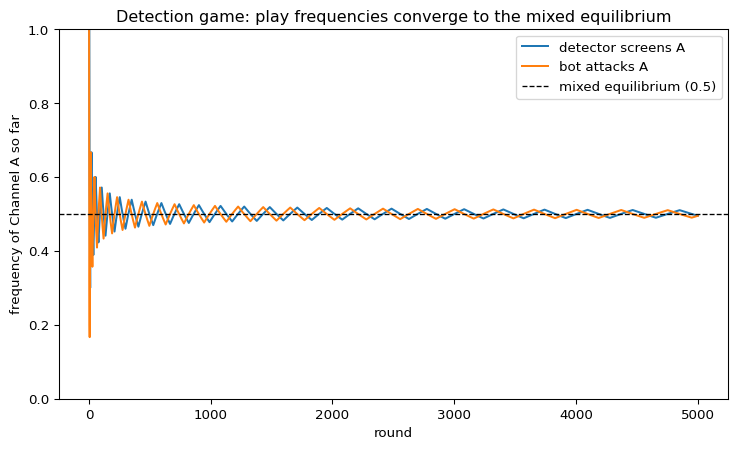

In [5]:
rounds = np.arange(1, len(history) + 1)
plt.figure(figsize=(9, 5))
plt.plot(rounds, detector_freq[:, 0], color="tab:blue", label="detector screens A")
plt.plot(rounds, bot_freq[:, 0], color="tab:orange", label="bot attacks A")
plt.axhline(0.5, color="black", linestyle="--", linewidth=1, label="mixed equilibrium (0.5)")
plt.ylim(0, 1)
plt.xlabel("round")
plt.ylabel("frequency of Channel A so far")
plt.title("Detection game: play frequencies converge to the mixed equilibrium")
plt.legend()
plt.show()

Two things to pay attention to here. First, the actions themselves never
settle: the sequence of moves keeps switching channels forever, just
like the last-move reactor in Notebook 1. Second, the *frequencies*
converge, and they converge to the 50/50 mixed equilibrium we derived
with the indifference principle. Nobody in this simulation ever flipped
a coin, yet equilibrium randomization emerged anyway, as the long-run
proportions of a deterministic learner.

This is the **belief interpretation of mixed strategies**. The 50/50 in
the equilibrium does not have to describe a human flipping a coin to
decide. It can describe the stable belief that an observer, or an
opponent, forms from watching play: attack rates, screening rates, the
frequencies in output files. For games of pure conflict this is a
theorem, proved by Robinson (1951): in any zero-sum game, fictitious
play’s frequencies converge to a Nash equilibrium. Our learner is
guaranteed to solve the entire class of games that broke Notebook 1’s
reactor.

### 3.1 Learning in the data pipeline game

What does the belief-based learner do when a game has several
equilibria? The data pipeline game has three: (Adopt, Adopt), (Legacy,
Legacy), and the 75/25 mix. Recall the tipping-point reading: Adopt is a
best response only when your belief that the rival adoption probability
is above 75%. Now think about what fictitious play believes early on.
After a start where one firm adopted and the other did not, each belief
sits at 50%, well short of the tipping point, so both firms play Legacy,
which drags the beliefs about Adopt lower still. The process feeds on
itself.

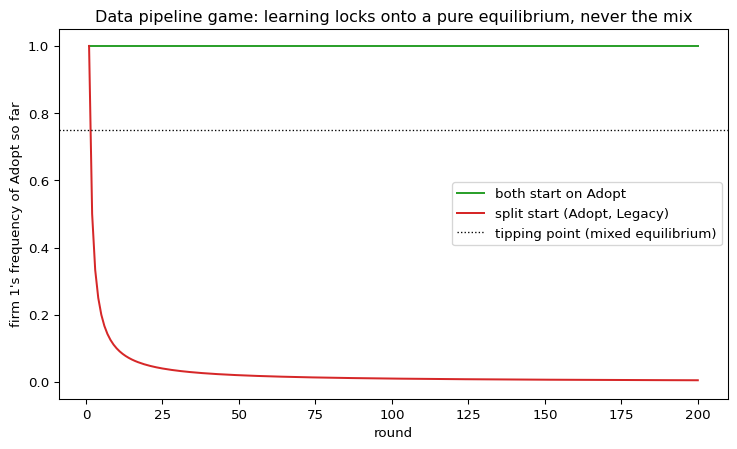

In [6]:
starts = {"both start on Adopt": (0, 0), "split start (Adopt, Legacy)": (0, 1)}

plt.figure(figsize=(9, 5))
for (label, start), color in zip(starts.items(), ["tab:green", "tab:red"]):
    h = fictitious_play(S, S.T, rounds=200, start=start)
    f = running_freq(h[:, 0], 2)
    plt.plot(np.arange(1, 201), f[:, 0], color=color, label=label)
plt.axhline(0.75, color="black", linestyle=":", linewidth=1,
            label="tipping point (mixed equilibrium)")
plt.ylim(-0.05, 1.05)
plt.xlabel("round")
plt.ylabel("firm 1's frequency of Adopt so far")
plt.title("Data pipeline game: learning locks onto a pure equilibrium, never the mix")
plt.legend()
plt.show()

From a coordinated start, adoption is logical and the pair stays at
(Adopt, Adopt) forever. From the split start, both firms retreat to
Legacy within a couple of rounds and never come back, and the same
happens from the mirror-image split start. The 75/25 equilibrium never
appears in any run. It is a knife edge: beliefs exactly *at* the tipping
point would keep both firms indifferent, but the slightest history to
either side tips play to a pure equilibrium.

## 4. Shapley’s game

At this point fictitious play looks strong. It finds the mixed
equilibrium in games of pure conflict, and it settles into sensible pure
equilibria in coordination games. Shapley (1964) built a game
specifically to end that winning streak, and it is a game you already
know how to play: rock-paper-scissors, with one twist. A win pays 1, and
everything else, a loss *or a tie*, pays 0.

In [7]:
rps = ["Rock", "Paper", "Scissors"]
A_s = np.array([[0, 0, 1],
                [1, 0, 0],
                [0, 1, 0]])   # row's wins: Rock beats Scissors, Paper beats Rock, Scissors beats Paper
shapley_game = nash.Game(A_s, A_s.T)

for eq in shapley_game.support_enumeration():
    print(eq)

(array([0.33333333, 0.33333333, 0.33333333]), array([0.33333333, 0.33333333, 0.33333333]))

Ordinary rock-paper-scissors, where a win pays 1 and a loss costs 1, is
zero-sum, so Robinson’s theorem applies and fictitious play converges to
the unique equilibrium, a third on each action (rock with 1/3, paper
with 1/3 and scissors with 1/3). Shapley’s version changes the price of
losing: a loss costs nothing instead of costing a point, so a decided
cell’s payoffs sum to 1 rather than 0. That breaks the zero-sum
structure and breaks the guarantee. The equilibrium itself survives,
`support_enumeration` finds exactly one, mixing one third on each
action. Watch the learner try to reach it.

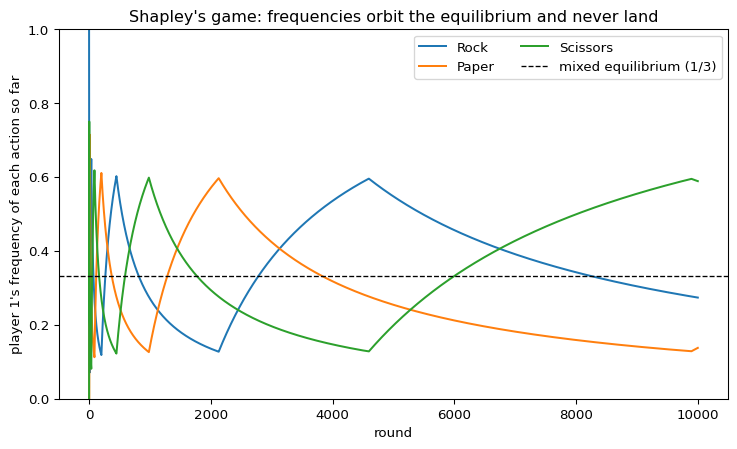

In [8]:
h = fictitious_play(A_s, A_s.T, rounds=10000, start=(0, 1))
f = running_freq(h[:, 0], 3)

plt.figure(figsize=(9, 5))
for k, (action, color) in enumerate(zip(rps, ["tab:blue", "tab:orange", "tab:green"])):
    plt.plot(np.arange(1, 10001), f[:, k], color=color, label=action)
plt.axhline(1/3, color="black", linestyle="--", linewidth=1, label="mixed equilibrium (1/3)")
plt.ylim(0, 1)
plt.xlabel("round")
plt.ylabel("player 1's frequency of each action so far")
plt.title("Shapley's game: frequencies orbit the equilibrium and never land")
plt.legend(ncols=2)
plt.show()

The frequencies never settle. Play chases itself around the circle, Rock
invites Paper, Paper invites Scissors, Scissors invites Rock, and each
lap takes longer than the one before, because the beliefs are averages
over an ever-heavier history and turn more and more slowly. The
frequencies keep overshooting a third and orbiting it forever. This is
the famous example promised at the end of Notebook 1: a game with a
perfectly well-defined equilibrium that a natural learning process never
finds.

Whether learning converges is a joint property of the game and the
learning rule. Upgrading the learner from a one-move memory to full
beliefs enlarged the set of games it can solve, it did not make the
problem go away.

## 5. Conclusion

We gave our player a memory and a model. Mixed strategies gave us the
language to put that memory to work: a strategy can be a probability,
expected payoffs decide best responses, and the indifference principle
pins down equilibrium mixes, with each player’s probabilities set by the
opponent’s payoffs. In the detection game, equilibrium randomization
emerged as the long-run frequencies of two deterministic learners. In
the data pipeline game, learning read the 75/25 mix as a tipping point
of beliefs and reliably fell off it to a pure equilibrium, favouring the
safe one. And in Shapley’s game, learning failed, cycling forever.

Both notebooks so far share one assumption: every game is played once,
by players who will never meet again, so nothing done today can be
rewarded or punished tomorrow. Dropping that assumption changes
everything, including the fate of the prisoner’s dilemma from [Notebook
1](notebook_01_games_best_responses_nash.qmd). [Notebook
3](notebook_03_repeated_games_axelrod_tournament.qmd) lets the same
players meet every day, remember, and retaliate: repeated games, and the
emergence of cooperation.

### References

-   Brown, G. W. (1951). *Iterative solution of games by fictitious
    play.* In T. C. Koopmans (Ed.), Activity Analysis of Production and
    Allocation. Wiley. The original fictitious play paper.
-   Fudenberg, D., & Levine, D. K. (1998). *The Theory of Learning in
    Games.* MIT Press. The standard reference for everything in this
    notebook.
-   Knight, V., & Campbell, J. (2018). *Nashpy: A Python library for the
    computation of Nash equilibria.* Journal of Open Source Software,
    3(30), 904. https://nashpy.readthedocs.io
-   Li, H. *ECON 221 and ECON 421 course outlines.* University of
    British Columbia.
    https://lihao.microeconomics.ca/li_content/econ421/outline.html
-   Osborne, M. J. (2004). *An Introduction to Game Theory.* Oxford
    University Press. (Chapter 4 covers mixed strategy equilibrium.)
-   Robinson, J. (1951). *An iterative method of solving a game.* Annals
    of Mathematics, 54(2), 296-301. The proof that fictitious play
    converges in zero-sum games.
-   Shapley, L. S. (1964). *Some topics in two-person games.* In M.
    Dresher, L. S. Shapley, & A. W. Tucker (Eds.), Advances in Game
    Theory. Princeton University Press. The 3x3 counterexample of
    section 4.